# This is going to be the first iteration of my graphs for my orchestrator

- The first task was to check the win-rate of an agent change as we changed their meta data.
- So we first had ZEN vs GARNET.
- They were my custom AI that would do an action every 6 frames.
- I realized real fast that using wall time was affecting their performance, because in headless mode, time doesn't move the same.
- Hence, we will have 2 graphs, showing headless and visual. They are really the same.

## Agent Settings

- They will do a kick (if in range) every 6 frames, otherwise, they will walk.
- We read their range from their motion data.

### Task

We are going to write something that will fetch the results and graph them plainly

In [ ]:
%load_ext autoreload
%autoreload 2

import os
import pathlib
import re
import functions as f

import pandas

import constants as c
import MotionClasses.MotionEditor as me
from MotionClasses.MotionHeaders import MotionHeaders as headers
from MotionClasses.MotionNames import MotionNames as command_names

experiment_name: str = 'mcts_z_l_z_d_u_l_ge_u_z_sx_u_z_hae_u_l_hd_d'
# experiment_name: str = 'mcts_z_l_z_d_u_l_ge_u2_z_sx_u_z_hae2_u_l_hd_d02'

custom_motion_folder = os.path.join('custom_motions', experiment_name)
characters = [
    c.CHARACTERS.ZEN,
    c.CHARACTERS.LUD,
]

motion_diffs_player_one = me.get_motion_diffs(
    characters[0],
    [
        me.read_motion_file(motion_file)  #
        for motion_file in pathlib.Path(custom_motion_folder).glob(f'{characters[0].lower()}*.csv')
    ],
)

motion_diffs_player_two = me.get_motion_diffs(
    characters[1],
    [
        me.read_motion_file(motion_file)  #
        for motion_file in pathlib.Path(custom_motion_folder).glob(f'{characters[1].lower()}*.csv')
    ],
)

player_one_changed_motion_headers = [*motion_diffs_player_one.columns]
player_two_changed_motion_headers = [*motion_diffs_player_two.columns]

# Right now we are coding under the assumption that we are incrementing the values for all motions.
# Once we upgrade to using the genetic algorithm, this will need refinement

gathered_player_one_motion_diffs: list[pandas.DataFrame] = []
gathered_player_two_motion_diffs: list[pandas.DataFrame] = []

for player_one_changed_motion_header in player_one_changed_motion_headers:
    motion_name = me.get_non_0_motion_name_in_diff(motion_diffs_player_one, player_one_changed_motion_header)
    gathered_player_one_motion_diffs.append(motion_diffs_player_one.xs(motion_name, level=1)[player_one_changed_motion_header])

for player_two_changed_motion_header in player_two_changed_motion_headers:
    motion_name = me.get_non_0_motion_name_in_diff(motion_diffs_player_two, player_two_changed_motion_header)
    gathered_player_two_motion_diffs.append(motion_diffs_player_two.xs(motion_name, level=1)[player_two_changed_motion_header])

player_one_changed_motion_headers = [f'{characters[0].lower()} - {player_one_changed_motion_header}' for player_one_changed_motion_header in player_one_changed_motion_headers]
player_two_changed_motion_headers = [f'{characters[1].lower()} - {player_two_changed_motion_header}' for player_two_changed_motion_header in player_two_changed_motion_headers]

motion_diffs_player_one = pandas.concat(
    gathered_player_one_motion_diffs,
    axis=1,
    keys=player_one_changed_motion_headers,
)

motion_diffs_player_two = pandas.concat(
    gathered_player_two_motion_diffs,
    axis=1,
    keys=player_two_changed_motion_headers,
)

experiment_regex = re.compile(rf'{re.escape(experiment_name)}_(\d+).*\.csv')

match_results: list[pandas.DataFrame] = []

for experiment_file in pathlib.Path('log/point').glob('*.csv'):
    match = experiment_regex.search(experiment_file.name)

    if match:
        experiment_number = int(match.group(1))
        match_result = f.read_match_results(experiment_file)

        match_result[c.PointHeaderNames.SIMULATION_NUMBER] = experiment_number
        match_result[c.PointHeaderNames.SIMULATION_NUMBER] = match_result[c.PointHeaderNames.SIMULATION_NUMBER].astype('int16')
        match_results.append(match_result)

match_results: pandas.DataFrame = pandas.concat(match_results, ignore_index=True)
match_results.set_index(c.PointHeaderNames.SIMULATION_NUMBER, inplace=True)


if not motion_diffs_player_one.empty:
    match_results = match_results.join(motion_diffs_player_one)

if not motion_diffs_player_two.empty:
    match_results = match_results.join(motion_diffs_player_two)

match_results.sort_index(inplace=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


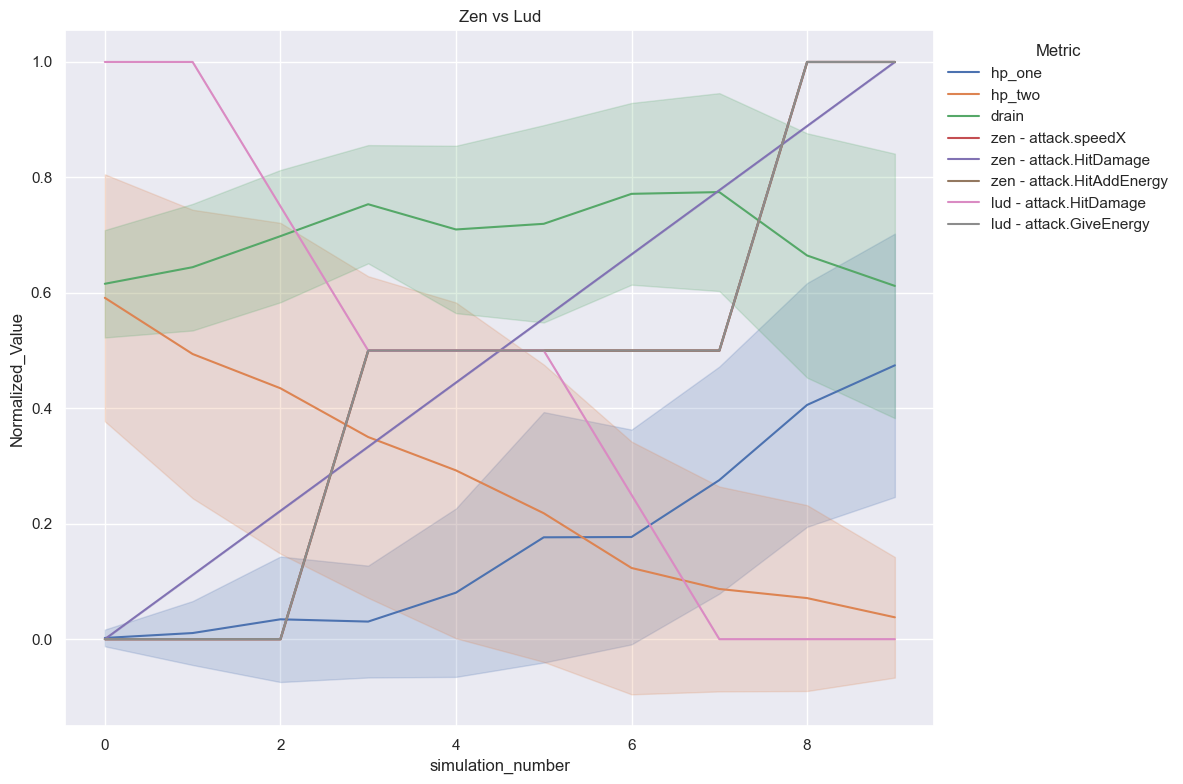

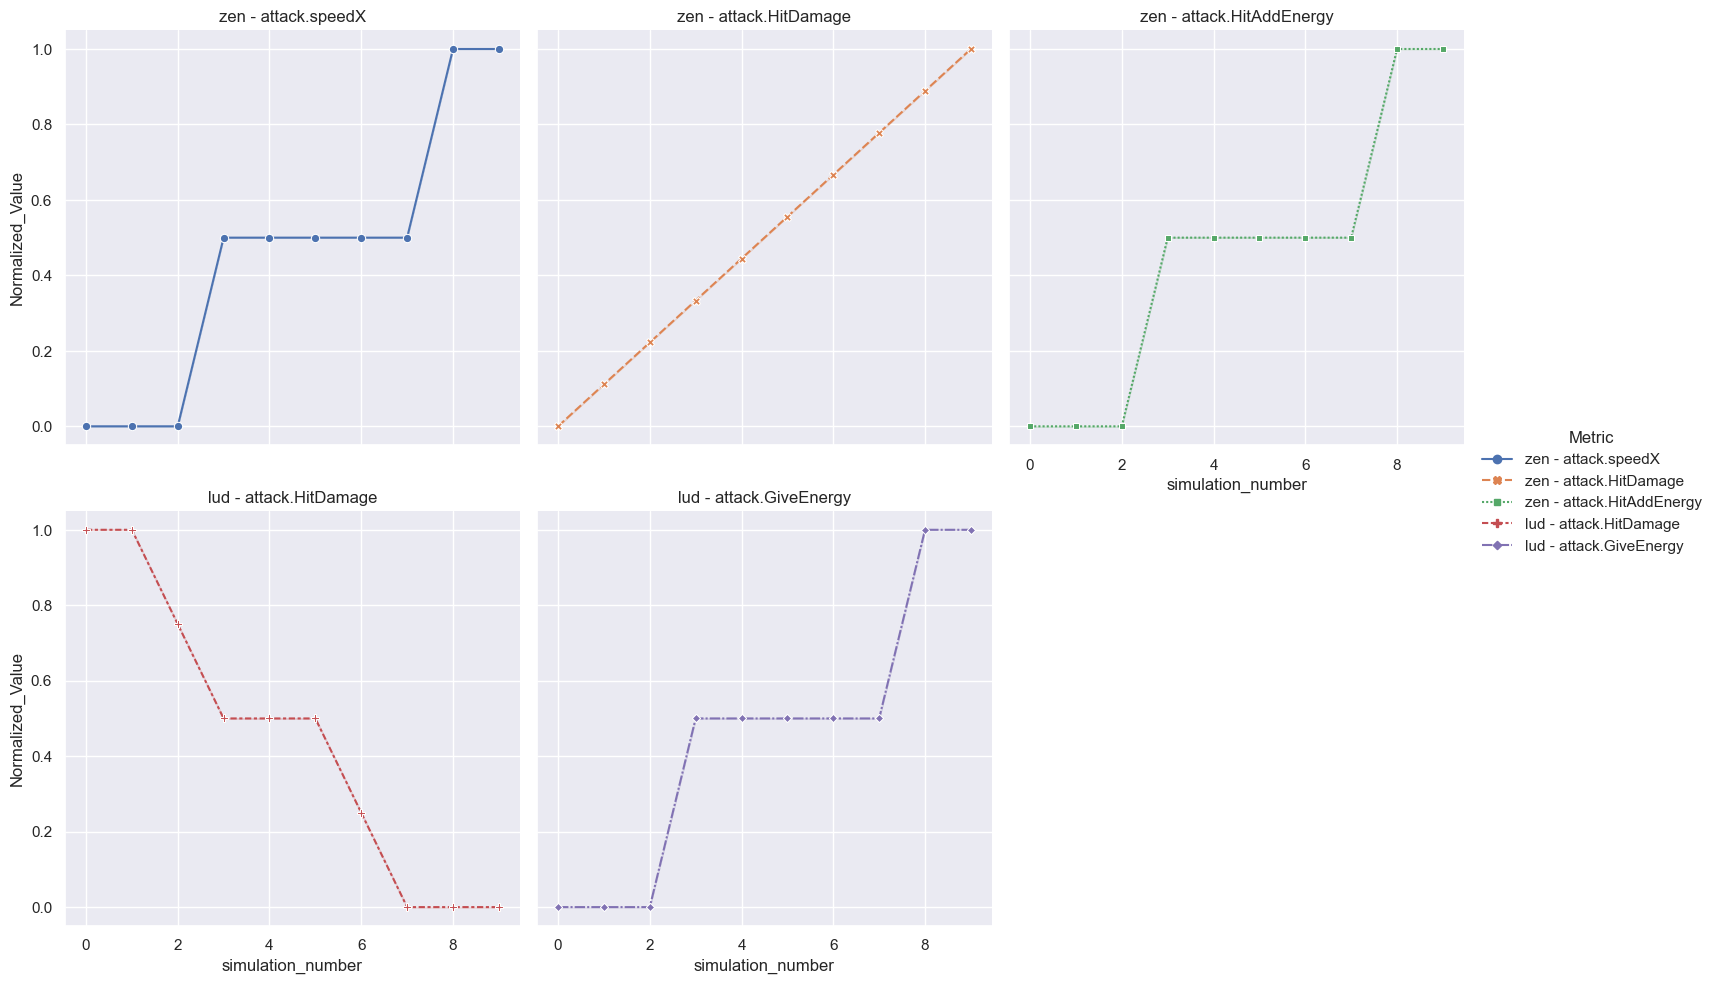

In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import seaborn as sns

import constants as c
import MotionClasses.MotionEditor as me
from MotionClasses.MotionHeaders import MotionHeaders as headers
from MotionClasses.MotionNames import MotionNames as command_names

sns.set_theme(style='darkgrid')

plot_data = match_results.copy().reset_index()

plot_data[c.PointHeaderNames.HP_ONE] /= c.PLAYER_HP
plot_data[c.PointHeaderNames.HP_TWO] /= c.PLAYER_HP
plot_data[c.PointHeaderNames.DRAIN] /= c.GAME_DURATION_SEC * 60

for player_one_changed_motion_header in player_one_changed_motion_headers:
    data_max = plot_data[player_one_changed_motion_header].max()
    data_min = plot_data[player_one_changed_motion_header].min()
    plot_data[player_one_changed_motion_header] = (
        plot_data[player_one_changed_motion_header] / data_max  #
        if data_max != 0
        else plot_data[player_one_changed_motion_header] / data_min * -1 + 1
    )

for player_two_changed_motion_header in player_two_changed_motion_headers:
    data_max = plot_data[player_two_changed_motion_header].max()
    data_min = plot_data[player_two_changed_motion_header].min()
    plot_data[player_two_changed_motion_header] = (
        plot_data[player_two_changed_motion_header] / data_max  #
        if data_max != 0
        else plot_data[player_two_changed_motion_header] / data_min * -1 + 1
    )

plot_df_long = plot_data.melt(
    id_vars=[c.PointHeaderNames.SIMULATION_NUMBER],
    value_vars=[
        c.PointHeaderNames.HP_ONE,
        c.PointHeaderNames.HP_TWO,
        c.PointHeaderNames.DRAIN,
        *player_one_changed_motion_headers,
        *player_two_changed_motion_headers,
    ],
    var_name='Metric',
    value_name='Normalized_Value',
)


plt.figure(figsize=(12, 8))

line_plot = sns.lineplot(
    data=plot_df_long,
    x=c.PointHeaderNames.SIMULATION_NUMBER,
    y='Normalized_Value',
    # dashes=False,
    # markers=True,
    hue='Metric',
    # style='Metric',
    errorbar='sd',
)

sns.move_legend(
    line_plot,
    'upper left',
    bbox_to_anchor=(1, 1),
    frameon=False
)

# 3. Finalize labels
line_plot.set_title('Zen vs Lud')

plt.tight_layout()
plt.show()

motion_plot_data = plot_df_long[
    plot_df_long['Metric'].isin(
        [
            *player_one_changed_motion_headers,
            *player_two_changed_motion_headers,
        ]
    )
]

# 3. Create the Facet Grid
g = sns.relplot(
    data=motion_plot_data,
    x=c.PointHeaderNames.SIMULATION_NUMBER,
    y='Normalized_Value',
    col='Metric',
    col_wrap=3,
    kind='line',
    hue='Metric',
    style='Metric',
    markers=True,
)

g.set_titles('{col_name}')
plt.show()

In [3]:

from pyftg.socket.aio.gateway import Gateway
import functions as f
import constants as c

try:
    gateways = f.create_gateways(8000, 9000, limit=c.NO_ENGINES)

    # Attempt to reference the Java class
    mcts_class = gateways[0].jvm.aiinterface.MctsAi23i
    print("Success: MctsAi23i found in the Java environment!")
except Exception as e:
    print(f"Error: Could not find MctsAi23i. {e}")

Error: Could not find MctsAi23i. 'Gateway' object has no attribute 'jvm'


In [1]:
import os
import MotionClasses.MotionEditor as me
import constants as c
import pandas

zen_motion: pandas.DataFrame = me.read_motion_file(
    os.path.join(
        c.DEFAULT_MOTIONS_PATH,
        'ZEN',
        c.MOTIONS_FILE_NAME,
    )
)

numerical_rows = zen_motion.select_dtypes('number')

In [2]:
import MotionClasses.MotionHeaders as headers

print(zen_motion.columns)
print(numerical_rows.columns)
print(headers.MotionHeaders.MAPPER)

Index(['frameNumber', 'speedX', 'speedY', 'hitAreaLeft', 'hitAreaRight',
       'hitAreaUp', 'hitAreaDown', 'state', 'attack.hitAreaLeft',
       'attack.hitAreaRight', 'attack.hitAreaUp', 'attack.hitAreaDown',
       'attack.speedX', 'attack.speedY', 'attack.StartUp', 'attack.Active',
       'attack.HitDamage', 'attack.GuardDamage', 'attack.StartAddEnergy',
       'attack.HitAddEnergy', 'attack.GuardAddEnergy', 'attack.GiveEnergy',
       'attack.ImpactX', 'attack.ImpactY', 'attack.GiveGuardRecov',
       'attack.AttackType', 'attack.DownProp', 'cancelAbleFrame',
       'cancelAbleMotionLevel', 'motionLevel', 'control', 'landingFlag',
       'Image'],
      dtype='str')
Index(['frameNumber', 'speedX', 'speedY', 'hitAreaLeft', 'hitAreaRight',
       'hitAreaUp', 'hitAreaDown', 'attack.hitAreaLeft', 'attack.hitAreaRight',
       'attack.hitAreaUp', 'attack.hitAreaDown', 'attack.speedX',
       'attack.speedY', 'attack.StartUp', 'attack.Active', 'attack.HitDamage',
       'attack.GuardDa

In [ ]:
import numpy as np
from scipy.spatial.distance import pdist

t = np.array([
    [['g', 'g']],
    [['f', 'g']]
])

# print((t[0] - t[1]).sum())
# print(np.linalg.norm(t[0] - t[1]))

# print(np.sum(np.sqrt(pdist(t.reshape(2, -1), metric='hamming') * t.shape[1])))
pdist(t.reshape(2, -1), metric='hamming')

ValueError: Unsupported dtype <U1

In [2]:
from MotionClasses.MotionNames import MotionNames as motion_names
from MotionClasses.MotionHeaders import MotionHeaders as headers
import numpy as np
import functions as f
import constants as c


motion_rows = np.array([
    motion_names.MAPPER[motion_names.STAND_A],
    motion_names.MAPPER[motion_names.STAND_B],
])

header_cols = np.array([
    headers.HEADERS.index(headers.ATTACK_HIT_DAMAGE),
    headers.HEADERS.index(headers.ATTACK_HIT_ADD_ENERGY),
])

print(np.stack([motion_rows, header_cols]).T)

# 0: stand a d
# 1: stand b hae
variable_mapper = f.motion_cord_to_index_bulk(np.stack([motion_rows, header_cols]).T)
print(variable_mapper)
remapped_variable_mapper = f.motion_indices_to_cords(np.array(variable_mapper))
print(remapped_variable_mapper)
# delta_map = np.zeros(shape=zen_motion.shape, dtype=np.int64)

[[27 17]
 [28 20]]
[1529, 1588]
[[27 17]
 [28 20]]


In [7]:
import numpy as np

t = np.array([
    [1, 2],
    [3, 4]
])

rows = [0, 1]
cols = [1, 0]

t[rows, cols] = -1

print(t)

[[ 1 -1]
 [-1  4]]


In [5]:
import constants as c


AttributeError: 'CHARACTERS' object has no attribute 'index'

# Pymoo tester

In [1]:
import constants as c

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from GeneticAlgorithm.FightingIceProblem import FightingIceProblem
from pymoo.termination import get_termination

res = minimize(
    FightingIceProblem(),
    NSGA2(pop_size=2),
    get_termination(c.pymoo.TERMINATION.EVALUATION_LIMIT, 1),
    seed=1,
    save_history=True,
    verbose=True
)

Index(['frameNumber', 'speedX', 'speedY', 'hitAreaLeft', 'hitAreaRight',
       'hitAreaUp', 'hitAreaDown', 'state', 'attack.hitAreaLeft',
       'attack.hitAreaRight', 'attack.hitAreaUp', 'attack.hitAreaDown',
       'attack.speedX', 'attack.speedY', 'attack.StartUp', 'attack.Active',
       'attack.HitDamage', 'attack.GuardDamage', 'attack.StartAddEnergy',
       'attack.HitAddEnergy', 'attack.GuardAddEnergy', 'attack.GiveEnergy',
       'attack.ImpactX', 'attack.ImpactY', 'attack.GiveGuardRecov',
       'attack.AttackType', 'attack.DownProp', 'cancelAbleFrame',
       'cancelAbleMotionLevel', 'motionLevel', 'control', 'landingFlag',
       'Image'],
      dtype='str')
adjustments [[204 285]
 [ 57 284]
 [124 126]]
Index(['frameNumber', 'speedX', 'speedY', 'hitAreaLeft', 'hitAreaRight',
       'hitAreaUp', 'hitAreaDown', 'state', 'attack.hitAreaLeft',
       'attack.hitAreaRight', 'attack.hitAreaUp', 'attack.hitAreaDown',
       'attack.speedX', 'attack.speedY', 'attack.StartUp', 'att

# Experiment:
- Only going to track the uniqueness, and see if the constraint novelty search is working as expected. 

In [2]:
import constants as c

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from GeneticAlgorithm.FightingIceProblem import FightingIceProblem
from pymoo.termination import get_termination

res = minimize(
    problem=FightingIceProblem(),
    algorithm=NSGA2(),
    # termination=get_termination(c.pymoo.TERMINATION.EVALUATION_LIMIT, 1),
    termination=None,
    seed=1,
    save_history=True,
    verbose=True
)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      1 |             - |             -
     2 |      200 |      1 |  0.0000185466 |             f
     3 |      300 |      1 |  0.0000354884 |             f
     4 |      400 |      1 |  0.0000403414 |             f
     5 |      500 |      1 |  0.0000403414 |             f
     6 |      600 |      1 |  0.0000472024 |             f
     7 |      700 |      1 |  0.0000546628 |             f
     8 |      800 |      1 |  0.0000597253 |             f
     9 |      900 |      1 |  0.0000617201 |             f
    10 |     1000 |      1 |  0.0000619042 |             f
    11 |     1100 |      1 |  0.0000644690 |             f
    12 |     1200 |      1 |  0.0000644690 |             f
    13 |     1300 |      1 |  0.0000649519 |             f
    14 |     1400 |      1 |  0.0000659947 |             f
    15 |     1500 |      1 |  0.0000695840 |             f
    16 |     1600 |      1 |  0.0000698408 |            

In [15]:
import numpy as np

# np.set_printoptions(suppress=True, precision=4)
for row in res.X:
    print(", ".join(row.astype('str')))

399.93226314515266, 299.4423068072348, 0.05884925541761712, 0.026299998874231175, 399.34464913355885, 299.8868717855024
399.9227079003402, 299.53832278484396, 0.13678491524445924, 0.23535597136999742, 399.2252657626022, 299.8983160689791
399.9494690309057, 299.9832187829238, 0.009407507985861105, 0.05466778163187115, 399.31356639121543, 299.9012108927116
399.9231529776199, 299.4231674587957, 0.01297021550028158, 0.2416420048208343, 399.5116585497791, 299.9173065175919
399.87411006133794, 299.36805811175395, 0.12146351562415215, 0.05511091927416154, 399.8990933336292, 299.9767155313372
399.9205995695043, 299.92648311729084, 0.013308760082504645, 0.22809324567456174, 399.6505969134424, 299.91809766746803
399.4489031623429, 299.56708303535845, 0.11413635943234726, 0.05660941008545462, 399.9975293976245, 299.49378835721086
399.41756019231, 299.9339000049911, 0.18943676153889955, 0.23252547303931875, 399.9252437845029, 299.45778833109506
399.54356894148214, 299.39323419257704, 0.14714376621

# Experiment Results

We can observe that constraint novelty search is doing its JOB!
However, MASSIVE HOWEVER, we are not punishing the algorithm for producing agents that are close to each other.
We need to rethink how we can set this variable...
These results show that Zen is VERY different from Garnet, and Lud is VERY different from Garnet.
However! Zen is EXTREMELY similar to Lud.
This isn't punished and it needs to be.

# Experiment 2
Migrated to using a harmonic mean between the 3 objectives. 
Inspiration from F1 score calculation. 
Lets see how it goes

In [1]:
import constants as c

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from GeneticAlgorithm.FightingIceProblem import FightingIceProblem
from pymoo.termination import get_termination

res = minimize(
    problem=FightingIceProblem(),
    algorithm=NSGA2(),
    # termination=get_termination(c.pymoo.TERMINATION.EVALUATION_LIMIT, 1),
    termination=None,
    seed=1,
    save_history=True,
    verbose=True
)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      1 |             - |             -
     2 |      200 |      1 |  0.0000198406 |             f
     3 |      300 |      1 |  0.0000464823 |             f
     4 |      400 |      1 |  0.0000467054 |             f
     5 |      500 |      1 |  0.0000574494 |             f
     6 |      600 |      1 |  0.0000700497 |             f
     7 |      700 |      1 |  0.0000700497 |             f
     8 |      800 |      1 |  0.0000726392 |             f
     9 |      900 |      1 |  0.0000741341 |             f
    10 |     1000 |      1 |  0.0000743250 |             f
    11 |     1100 |      1 |  0.0000777790 |             f
    12 |     1200 |      1 |  0.0000777790 |             f
    13 |     1300 |      1 |  0.0000796056 |             f
    14 |     1400 |      1 |  0.0000818020 |             f
    15 |     1500 |      1 |  0.0000818020 |             f
    16 |     1600 |      1 |  0.0000830975 |            

In [2]:
import numpy as np

# np.set_printoptions(suppress=True, precision=4)
for row in res.X:
    print(", ".join(row.astype('str')))

399.8858225244321, 299.45647328799686, 0.19659066746274245, 299.97716188686496, 399.81910636597877, 0.006772408564373094
399.30566805475206, 299.2239335541648, 0.24546604277853462, 299.97800435645945, 399.86660156846955, 0.006970331743444214
399.97316567679417, 299.9531338625302, 0.005190903877503372, 299.99507764269, 399.9714420874886, 0.009277255092904068
399.97301675695843, 299.9490374673383, 0.010762783485098265, 299.9818982718737, 399.81563547791933, 0.0007274610335223364
399.575098685198, 299.5145007369701, 0.16529756442670085, 299.97365121627723, 399.71291726097695, 0.05212681360339992
399.6050393166103, 299.65366095760123, 0.06000592626351989, 299.80386475127887, 399.97442769137086, 0.05210381754958333
399.31941456135786, 299.8090160398842, 0.044535505826001055, 299.9836226712239, 399.99079799419974, 0.001796720606479174
399.99774612394503, 299.9447641258445, 0.19031732448958194, 299.895738030752, 399.7984313289378, 0.005467477495351198
399.5277543958599, 299.9464488052968, 0.1

# Experiment Results

We can now see better behavior
Zen is high in both
Garnet is low in the first, and high in the second
Lud is high in the first, and low in the second

# Experiment: Competitive Balance

We are going to have a look into that now. How fast and all.
If its too slow, we can look into parallelizing it, else, running more engines first

### Speed up notes
- This experiment was done on 20 nodes with 20 cores each!
- Starting to realize there might be an oversight...
- Go setup another experiment before tomorrow to show the speed up.
- We essentially only used 10 nodes, not all 20.
- We had a 45% utilization...

### Experiment Results
- We ran our first successful experiment on the cluster
- We only balanced competitive balance
- $\sigma$ was set to 0.2 because it seems that the GA struggles to efficiently learn when its at its usual value of 0.08.
- However, to be fair, there could have been other issues with those runs. So we will need to try them again.
- And if you look at these results!!! 
- So beautiful. 
- Got 20 non-dominated solutions.
- Only took 23 minutes (underutilized cluster though!)

### Notes for further work
- The variance in the experiments is very high. We need to perform experiments to find the optimal number of experiments 

In [13]:
import constants as c
import dill
import numpy as np

from pymoo.core.result import Result
from pymoo.core.algorithm import Algorithm

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from GeneticAlgorithm.FightingIceProblem import FightingIceProblem
from pymoo.termination import get_termination


with open('res.pkl', 'rb') as f:
    res: Result = dill.load(f)


print(f"{'gen':>5} | {'n_eval':>7} | {'n_nds':>5} | {'eps':>12}")
print("-" * 45)
# Taken from output file
print("time sec: 1366")


for i, generation in enumerate(res.history):
    n_gen = i + 1
    n_eval = generation.evaluator.n_eval
    n_nds = len(generation.opt)
    print(f"{n_gen:>5} | {n_eval:>7} | {n_nds:>5} | {generation.opt.get('F').min():>12.6f}")

print("non dominated solutions")
population = res.opt

genes: np.ndarray = population.get('X')
fitnesses: np.ndarray = population.get('F')

for gene, fitness in zip(genes, fitnesses, strict=True):
    print(f"Gene: [{", ".join(np.round(gene, 4).astype(str))}]")
    print(f"Fitness: {fitness}\n")

print()

for index, generation in enumerate(res.history):
    generation: Algorithm

    print(f"Generation: {index}\n")
    population = generation.pop

    genes: np.ndarray = population.get('X')
    fitnesses: np.ndarray = population.get('F')

    for gene, fitness in zip(genes, fitnesses, strict=True):
        print(f"Gene: [{", ".join(np.round(gene, 4).astype(str))}]")
        print(f"Fitness: {fitness}\n")

    print()


  gen |  n_eval | n_nds |          eps
---------------------------------------------
time sec: 1366
    1 |      20 |     2 |    -0.953904
    2 |      40 |    13 |    -0.953904
    3 |      60 |    15 |    -0.953904
    4 |      80 |    20 |    -0.953904
    5 |     100 |    20 |    -0.953904
    6 |     120 |    20 |    -0.953904
    7 |     140 |    20 |    -0.953904
    8 |     160 |    20 |    -0.953904
    9 |     180 |    20 |    -0.953904
   10 |     200 |    20 |    -0.953904
non dominated solutions
Gene: [272, 212, 191, 60, 309, 54]
Fitness: [ 0.         -0.95390395]

Gene: [272, 212, 191, 60, 309, 54]
Fitness: [ 0.         -0.95390395]

Gene: [272, 212, 191, 60, 309, 54]
Fitness: [ 0.         -0.95390395]

Gene: [272, 212, 191, 60, 309, 54]
Fitness: [ 0.         -0.95390395]

Gene: [272, 212, 191, 60, 309, 54]
Fitness: [ 0.         -0.95390395]

Gene: [270, 192, 289, 284, 309, 54]
Fitness: [ 0.         -0.95390395]

Gene: [270, 192, 289, 284, 309, 54]
Fitness: [ 0.         -

# Progress report

- So we have ran 2 experiments
- Testing uniqueness, and testing competitive balance.
- We have 1 of 2 tasks to pick from:
1. We make those experiments to find stable results
2. We work on uniqueness and competitive balance.
- TBH, I think they can both be done at the same time...
- So lets start with that.
- Also, one thing to note, I can already foresee some points of improvement...
- The genes that the GA comes up with are too high...
- Thats because to achieve this balance, it can be done at almost any threshold, as long as everything else stays the same.
- Hence, we will need to create some "excitement" metric of something along those lines.
- These 2 objectives alone aren't enough...

# Experiment
- We need to determine what the optimal number of runs are for reliable results.

In [1]:
import asyncio

import numpy as np

import functions as f
import GeneticAlgorithm.genetic_functions as gf
from MotionClasses.MotionHeaders import MotionHeaders as headers
from MotionClasses.MotionNames import MotionNames as motion_names

if __name__ == '__main__':
    motion_adjustments: dict[str, str] = {
        motion_names.STAND_A: headers.ATTACK_HIT_DAMAGE,
        motion_names.STAND_B: headers.ATTACK_HIT_ADD_ENERGY,
    }
    motion_coordinates = gf.get_motion_coordinates(motion_adjustments)
    gene: np.ndarray = np.array([272, 212, 191, 60, 309, 54], dtype=int)

    mutated_motions = gf.gene_to_motions(gene, motion_coordinates)

    average_win_rate = asyncio.run(
        gf.orchestrate_matches(
            mutated_motions=mutated_motions,
            no_matches=1,
            experiment_name='visual',
            experiment_suffix='',
            engine_multiplier=6,
            game_duration_sec=60,
            visual=False,
        )
    )

    competitive_balance: float = f.transform_win_rate(average_win_rate)

    print(f"Balance reward: {competitive_balance}")

RuntimeError: asyncio.run() cannot be called from a running event loop

# Experiment
- Now we had uniqueness + competitive balance
- Shockingly good results... A bit too good...
- Looks like it found max uniqueness and max competitive balance... Lets validate
- Did a small validation test (0.001699019186713894, 0.9726653350081863)
- Looks like this is really the case. 
- We can get pretty good balance not even adjusting a lot of values.
- However, as mentioned to Pravesh, we will need to look into other metrics, because the games are short and boring.

In [1]:
import constants as c
import dill
import numpy as np

from pymoo.core.result import Result
from pymoo.core.algorithm import Algorithm

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from GeneticAlgorithm.FightingIceProblem import FightingIceProblem
from pymoo.termination import get_termination


with open('res.pkl', 'rb') as f:
    res: Result = dill.load(f)


print(f"{'gen':>5} | {'n_eval':>7} | {'n_nds':>5} | {'eps':>12}")
print("-" * 45)
# Taken from output file
print("time sec: 1366")


for i, generation in enumerate(res.history):
    n_gen = i + 1
    n_eval = generation.evaluator.n_eval
    n_nds = len(generation.opt)
    print(f"{n_gen:>5} | {n_eval:>7} | {n_nds:>5} | {generation.opt.get('F').min():>12.6f}")

print("non dominated solutions")
population = res.opt

genes: np.ndarray = population.get('X')
fitnesses: np.ndarray = population.get('F')

for gene, fitness in zip(genes, fitnesses, strict=True):
    print(f"Gene: [{", ".join(np.round(gene, 4).astype(str))}]")
    print(f"Fitness: {fitness}\n")

print()

for index, generation in enumerate(res.history):
    generation: Algorithm

    print(f"Generation: {index}\n")
    population = generation.pop

    genes: np.ndarray = population.get('X')
    fitnesses: np.ndarray = population.get('F')

    for gene, fitness in zip(genes, fitnesses, strict=True):
        print(f"Gene: [{", ".join(np.round(gene, 4).astype(str))}]")
        print(f"Fitness: {fitness}\n")

    print()


  gen |  n_eval | n_nds |          eps
---------------------------------------------
time sec: 1366
    1 |      40 |     4 |    -0.717259
    2 |      80 |    37 |    -0.997968
    3 |     120 |    21 |    -0.997968
    4 |     160 |    20 |    -0.997968
    5 |     200 |    20 |    -0.997968
    6 |     240 |    20 |    -0.997968
    7 |     280 |    23 |    -0.997968
    8 |     320 |    20 |    -0.997968
    9 |     360 |    21 |    -0.999994
   10 |     400 |    21 |    -0.999994
non dominated solutions
Gene: [159, 138, 130, 230, 174, 15]
Fitness: [-0.00170069 -0.9979675 ]

Gene: [140, 107, 144, 224, 174, 14]
Fitness: [-0.00169902 -0.99999364]

Gene: [140, 107, 144, 224, 174, 14]
Fitness: [-0.00169902 -0.99999364]

Gene: [140, 107, 144, 224, 174, 14]
Fitness: [-0.00169902 -0.99999364]

Gene: [140, 107, 144, 224, 174, 14]
Fitness: [-0.00169902 -0.99999364]

Gene: [140, 107, 144, 224, 174, 14]
Fitness: [-0.00169902 -0.99999364]

Gene: [140, 107, 144, 224, 174, 14]
Fitness: [-0.00169